In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../')

from pathlib import Path

import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

data_dir = Path('/gpfs/data/fs71925/shepp123/frgs_6d/')
rmse_df = pd.read_csv('reconstruction_results.csv')
classification_df = pd.read_pickle('classification_results.pkl')

## contents

&emsp;0&emsp;on real space  
&emsp;1&emsp;trained on all vertices  
&emsp;&emsp;1-1&emsp;simple autoencoder  
&emsp;&emsp;1-2&emsp;contrastive autoencoder  
&emsp;2&emsp;trained on only 2 phases  
&emsp;&emsp;2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-3-2&emsp;contrastive autoencoder  
&emsp;3&emsp;trained on only 1 phase  
&emsp;&emsp;3-1&emsp;SC-phase  
&emsp;&emsp;3-2&emsp;AFM-phase  
&emsp;&emsp;3-3&emsp;FM-phase  
&emsp;4&emsp;correlation  
&emsp;5&emsp;convergence  

## visualize vertex

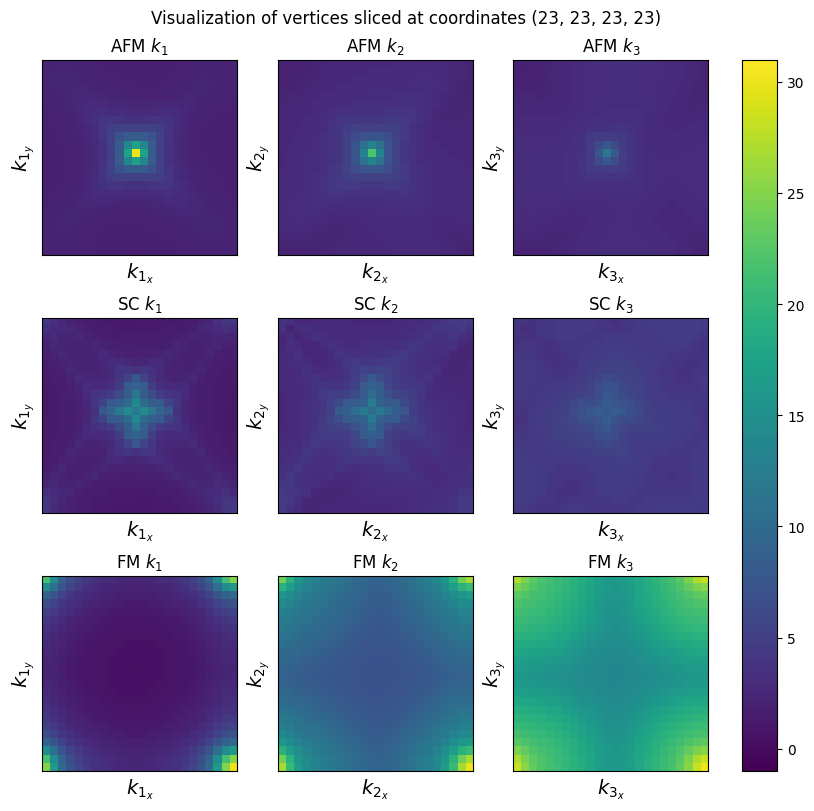

In [2]:
files_names = ['tp0.000000_mu0.000000', 'tp0.270000_mu1.080000', 'tp0.500000_mu2.000000']
vertices = [AutoEncoderVertex24x6Dataset.load_from_file(data_dir / f'{fn}.h5') for fn in files_names]
vertvis.plot_compare_slices(vertices)

## vertex statistics

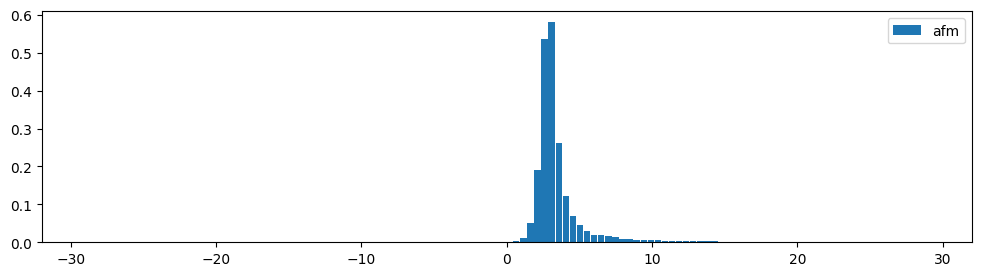

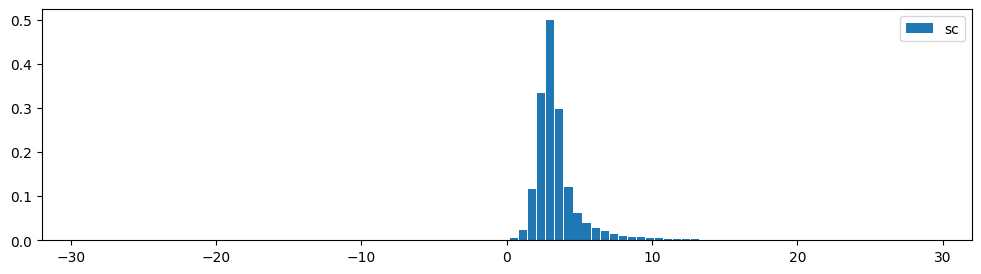

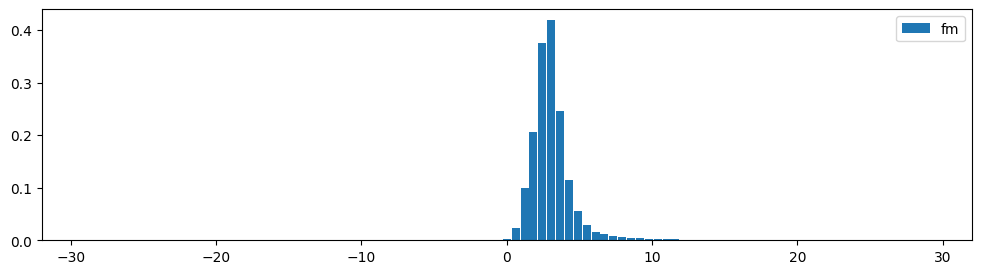

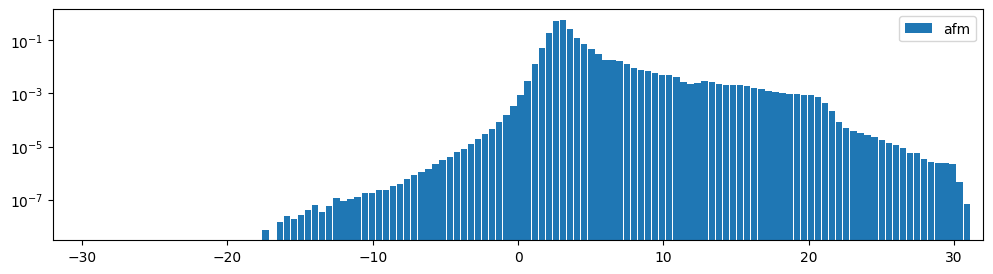

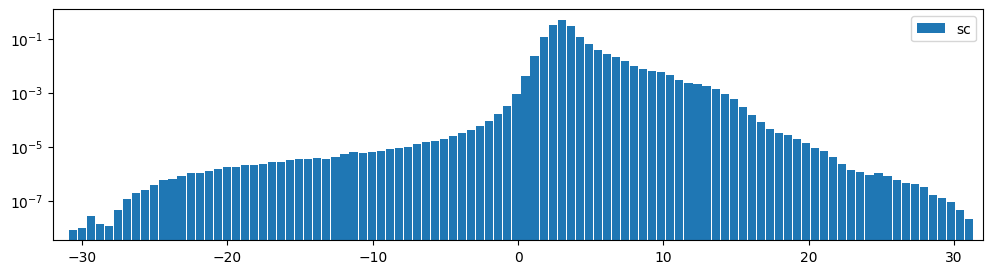

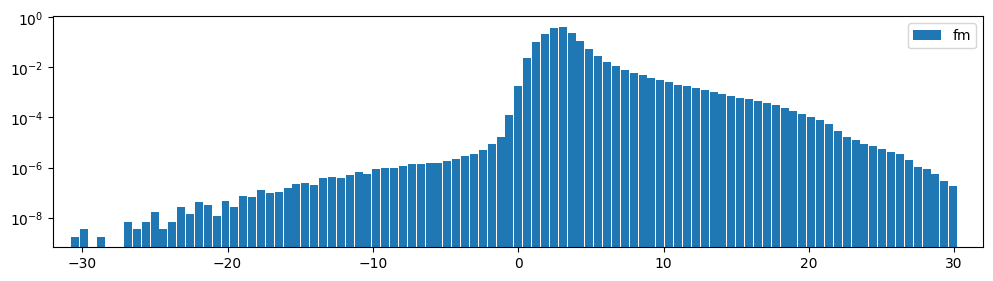

,min,max,mean,sum,std
afm,-17.621026,31.116854,3.516467,13440147922.163414,2.052257
sc,-30.943928,31.344199,3.435302,13129930305.072889,1.617395
fm,-30.830774,30.236403,3.128338,11956693254.854481,1.587498


In [2]:
verteval.vertex_statistics(data_dir)

## correlation

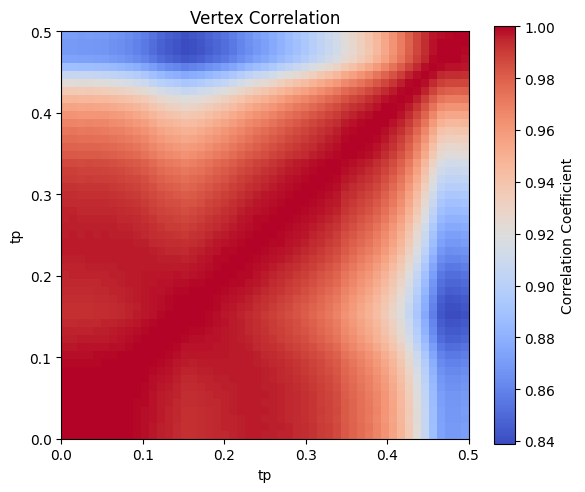

In [5]:
cor_mat = np.load(f'cor_mat_vertex24x6.npy')
vertvis.plot_correlation(cor_mat, "Vertex Correlation")

## compare autoencoder models

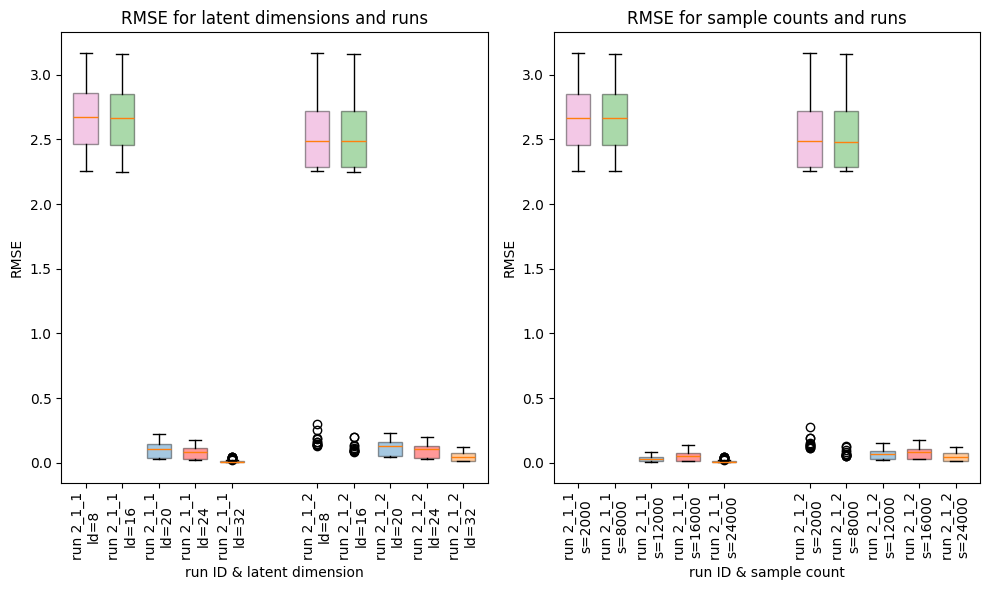

rmse
run_id ld s              
2_1_1  8  24000  2.683142
       16 24000  2.675942
       20 24000  0.104619
       24 24000  0.080148
       32 2000   2.676035
          8000   2.674256
          12000  0.035785
          16000  0.055903
          24000  0.013185
2_1_2  8  24000  2.069679
       16 24000  2.055018
       20 24000  0.120580
       24 24000  0.098643
       32 2000   2.063470
          8000   2.042674
          12000  0.068620
          16000  0.082347
          24000  0.050142

In [11]:
verteval.plot_all_rmses(rmse_df, figsize=(10, 6))

mean: 2.683142388932142, min: 2.2540576223933195, max: 3.1704341774024543


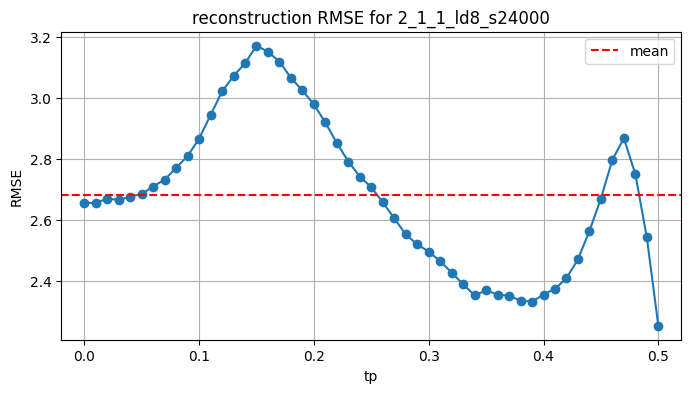

mean: 2.6759416311093522, min: 2.2519051169987305, max: 3.1623546175503128


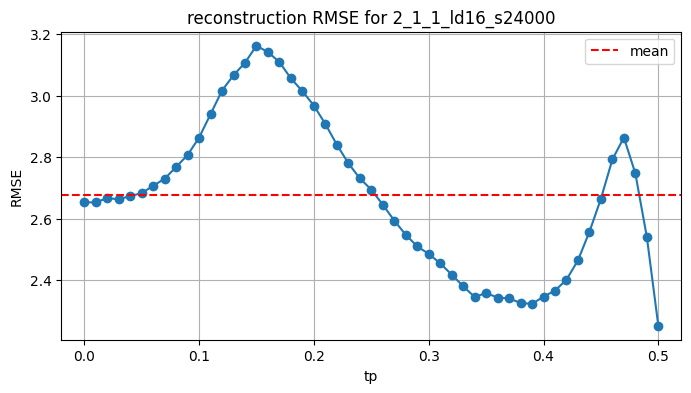

mean: 0.10461880741494109, min: 0.0255393413950728, max: 0.2225823101439754


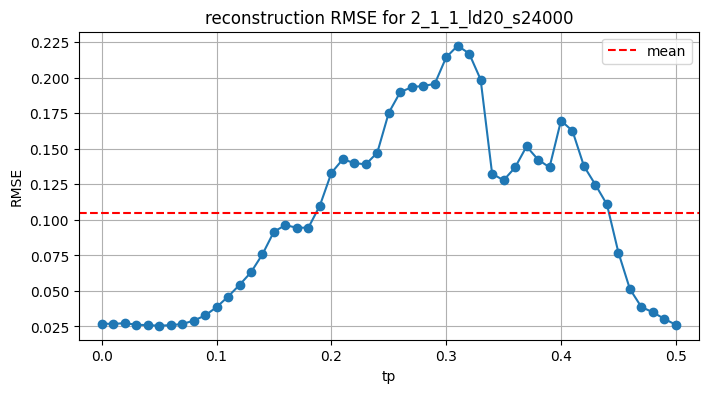

mean: 0.08014797751328752, min: 0.0184071548759922, max: 0.1798538481338467


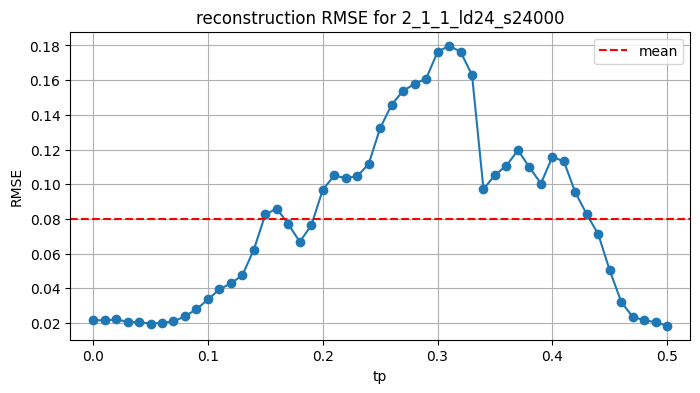

mean: 2.6760353622834434, min: 2.251820037131771, max: 3.1647240129072207


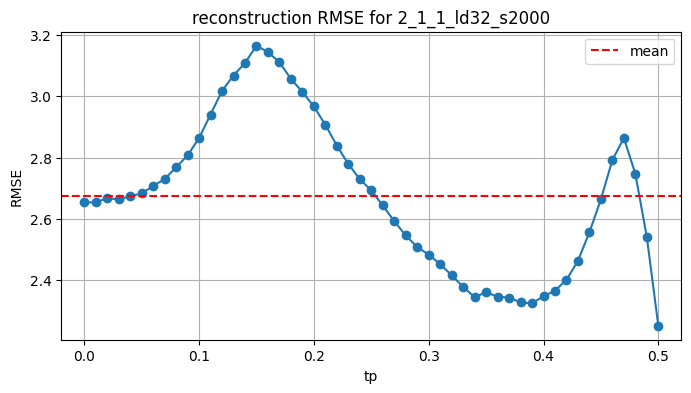

mean: 2.6742561183643114, min: 2.251697232227259, max: 3.160743367671952


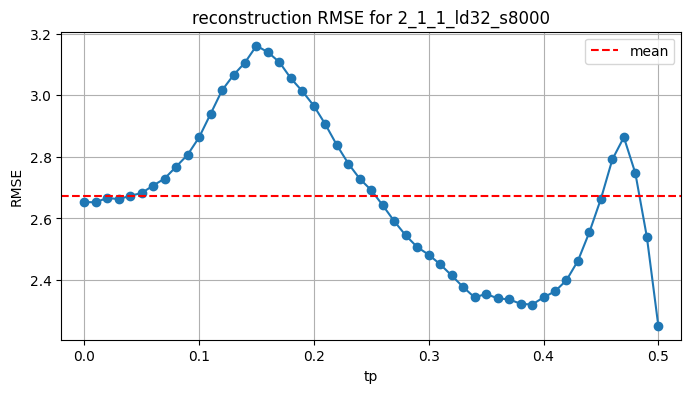

mean: 0.03578493106935763, min: 0.0095067765717626, max: 0.0858708956427293


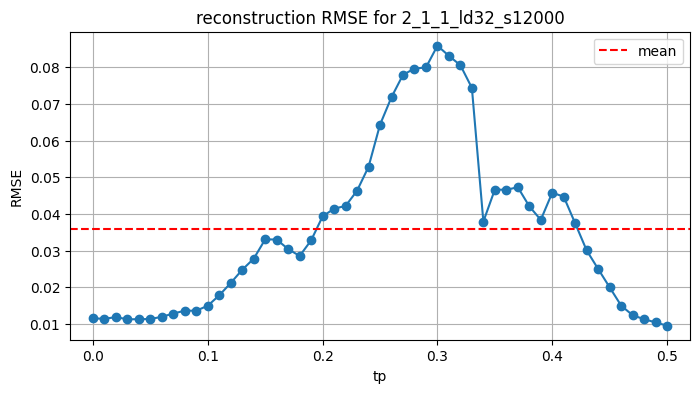

mean: 0.055902942182899026, min: 0.0113518980553117, max: 0.1351146024536373


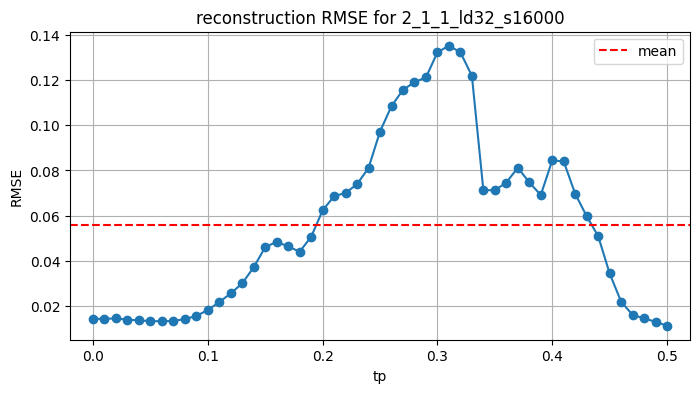

mean: 0.013184983189234209, min: 0.0050832275501072, max: 0.0458725036719538


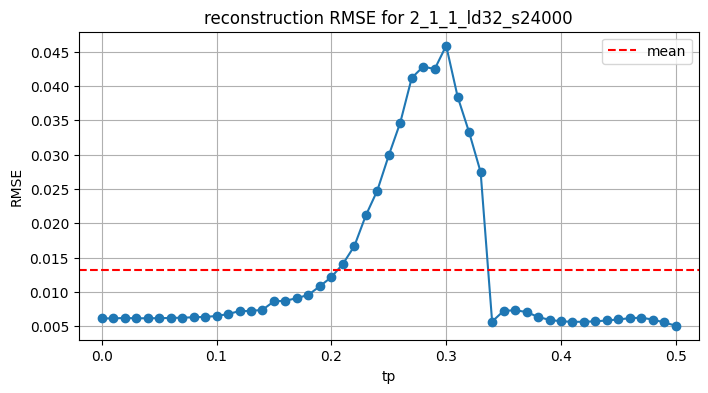

mean: 2.069679472533374, min: 0.1295202216423978, max: 3.167425182621654


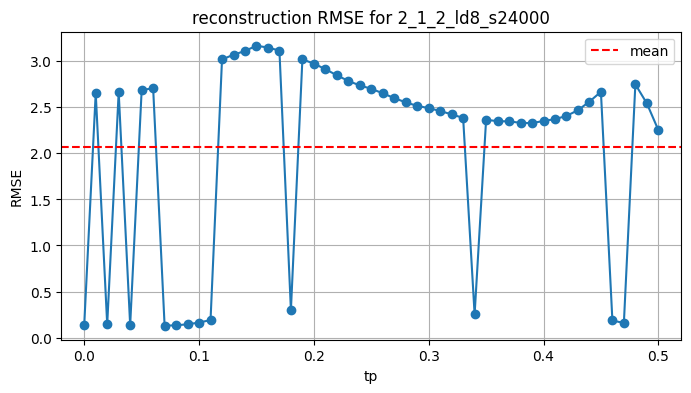

mean: 2.055018030318602, min: 0.0850051109597037, max: 3.163461476970084


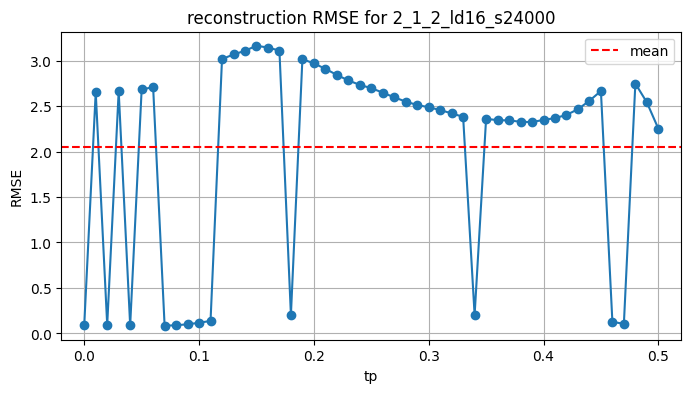

mean: 0.12057980778908887, min: 0.0412985417364552, max: 0.233764591226259


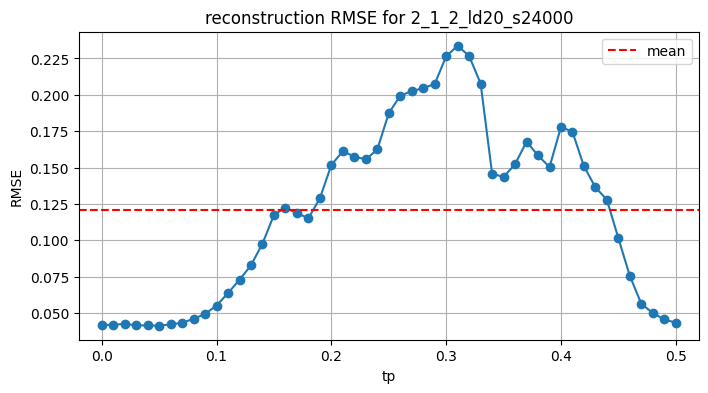

mean: 0.09864261256633138, min: 0.0296839522061908, max: 0.1960727584944648


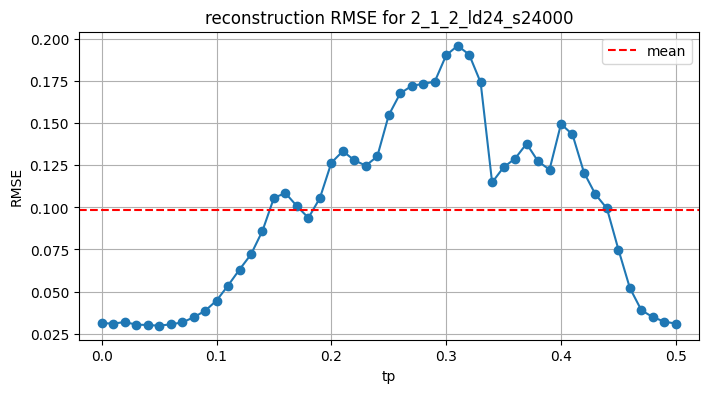

mean: 2.063469544273069, min: 0.1121170414727597, max: 3.1685246969891265


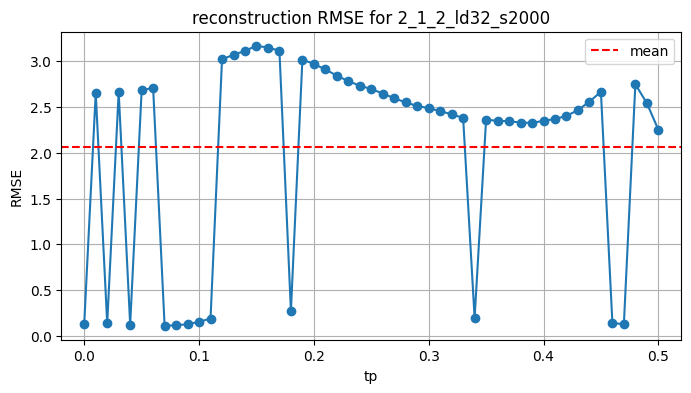

mean: 2.04267429678966, min: 0.05179313569046, max: 3.16187933072302


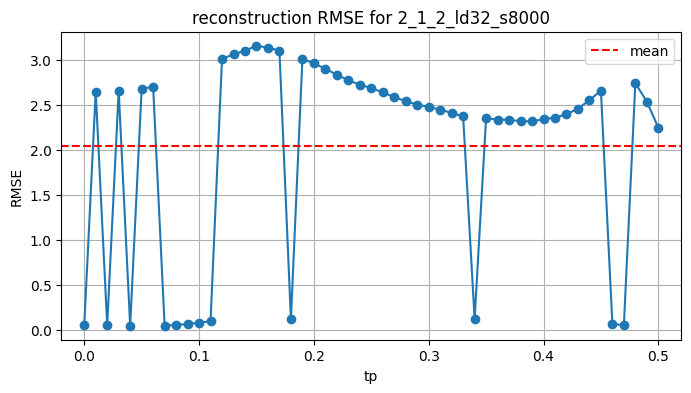

mean: 0.0686202417961813, min: 0.0213086456672753, max: 0.1508856340845076


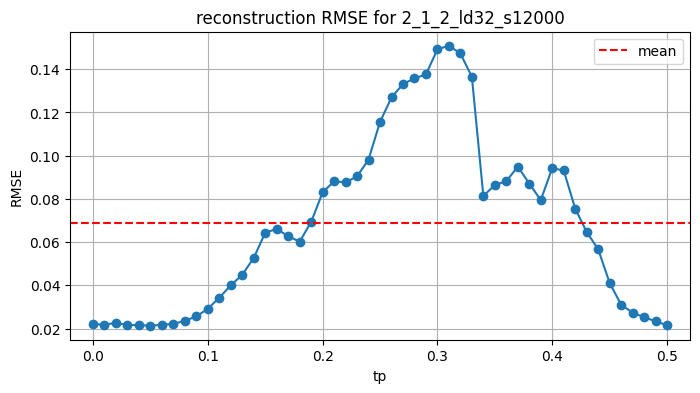

mean: 0.08234654258226756, min: 0.0267415227178833, max: 0.175533211487273


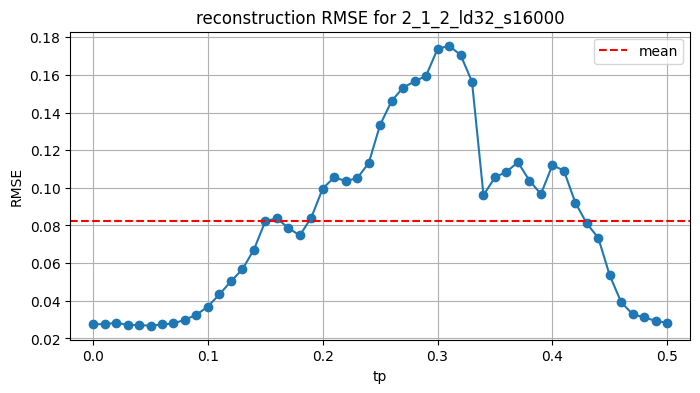

mean: 0.050142020039601116, min: 0.0099877950544564, max: 0.1212516075643841


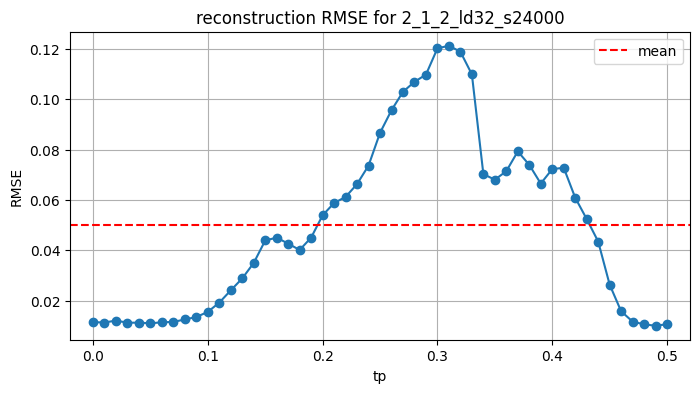

In [12]:
grouped_df = rmse_df.groupby(['run_id', 'ld', 's'])
for (run_id, ld, s), group in grouped_df:
    verteval.print_rmses(group, f'{run_id}_ld{ld}_s{s}')

## convergence

In [9]:
from pathlib import Path

base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/'
folders = sorted([f.name for f in Path(base_path).iterdir() if f.is_dir()])
labels = {
    '1_1': '1-1 all vertices, simple AE',
    '1_2': '1-2 all vertices, contrastive AE',
    '2_1_1': '2-1-1 exclude SC, simple AE',
    '2_1_2': '2-1-2 exclude SC, contrastive AE',
    '2_2_1': '2-2-1 exclude AFM, simple AE',
    '2_2_2': '2-2-2 exclude AFM, contrastive AE',
    '2_3_1': '2-3-1 exclude FM, simple AE',
    '2_3_2': '2-3-2 exclude FM, contrastive AE',
    '3_1': '3-1 SC only, simple AE',
    '3_2': '3-2 AFM only, simple AE',
    '3_3': '3-3 FM only, simple AE',
}

filtered_folders = folders  # set this to plot only some runs
filtered_labels = []
for f in filtered_folders:
    fsplit = f.split('_')
    pref, suff = '_'.join(fsplit[:-1]), fsplit[-1]
    filtered_labels.append(f"{labels[pref]} ({suff})")
tensorboard_data = vis.get_tensorboard_data(base_path, filtered_folders, filtered_labels)
tensorboard_stats = vis.get_tensorboard_statistics(tensorboard_data)
tensorboard_stats

,wall_time,epoch
run,,
"1-1 all vertices, simple AE (ld32)",35.96,21895
"1-2 all vertices, contrastive AE (ld32)",14.95,24999
"2-1-1 exclude SC, simple AE (ld16)",2.12,2162
"2-1-1 exclude SC, simple AE (ld24)",2.38,2408
"2-1-1 exclude SC, simple AE (ld32)",24.26,24999
"2-1-1 exclude SC, simple AE (ld8)",2.94,2993
"2-1-1 exclude SC, simple AE (s16000)",3.02,4677
"2-1-1 exclude SC, simple AE (s2000)",0.47,4905
"2-1-1 exclude SC, simple AE (s8000)",1.33,3974


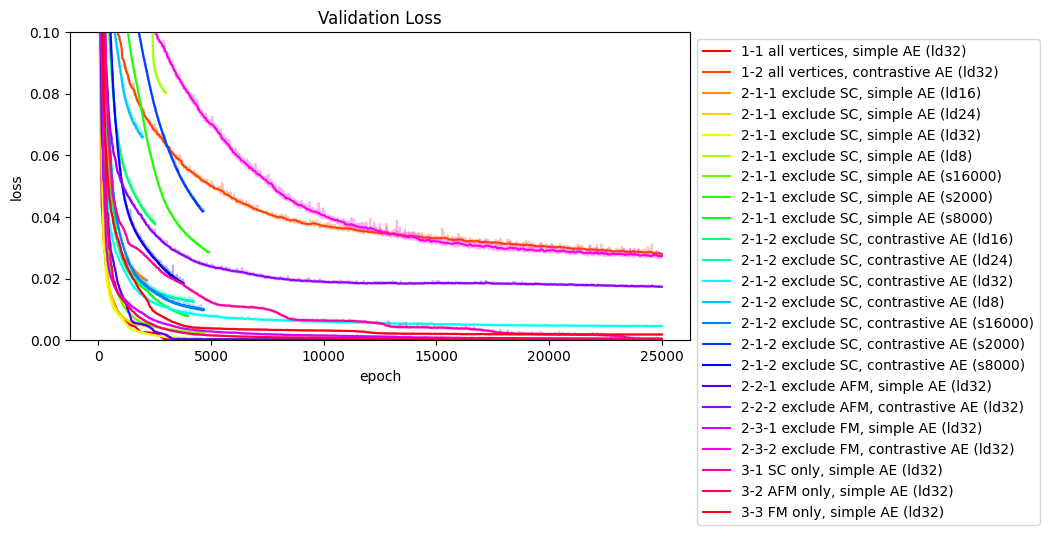

In [10]:
vis.plot_loss_progress(tensorboard_data.dropna(), labels, y_max=0.1, log=False)

## compare phase classifier models

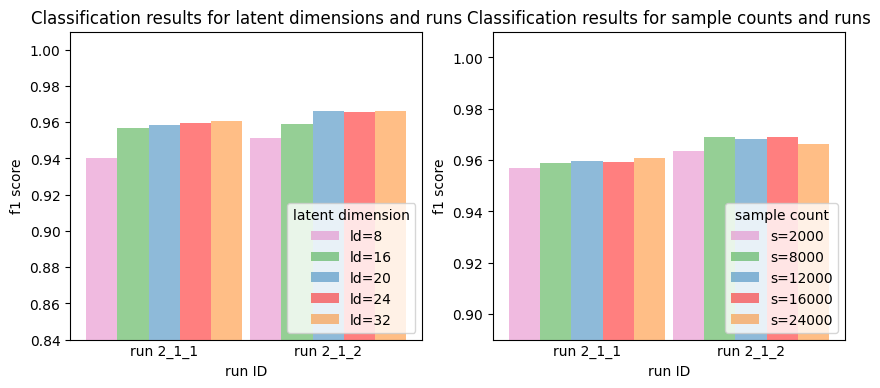

f1
run_id ld s              
2_1_1  8  24000  0.940110
       16 24000  0.957021
       20 24000  0.958681
       24 24000  0.959446
       32 2000   0.956765
          8000   0.958727
          12000  0.959546
          16000  0.959113
          24000  0.960729
2_1_2  8  24000  0.951040
       16 24000  0.959179
       20 24000  0.966148
       24 24000  0.965585
       32 2000   0.963471
          8000   0.968983
          12000  0.967969
          16000  0.968869
          24000  0.966148

In [13]:
verteval.plot_classification_results(classification_df, figsize=(10, 4))

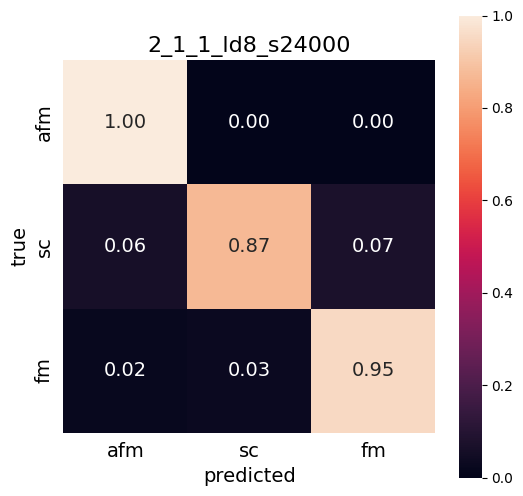

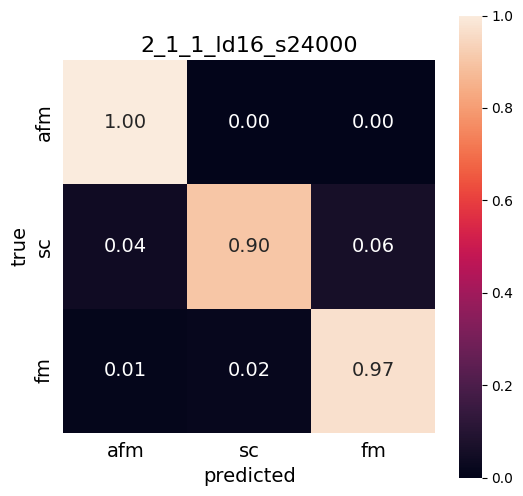

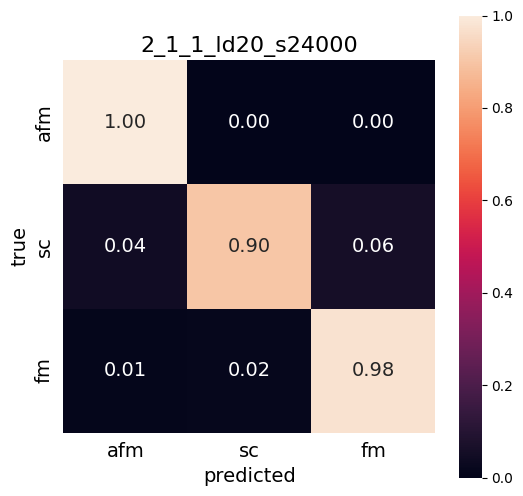

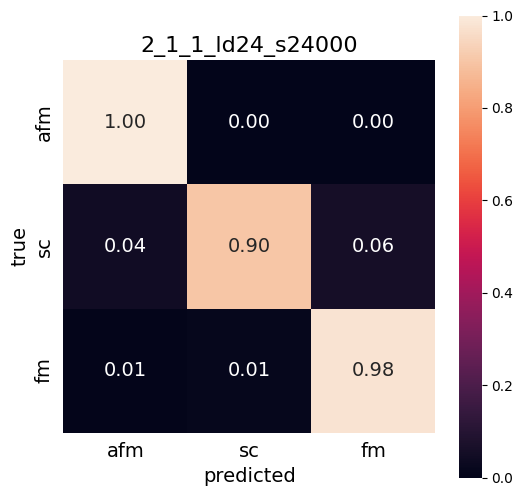

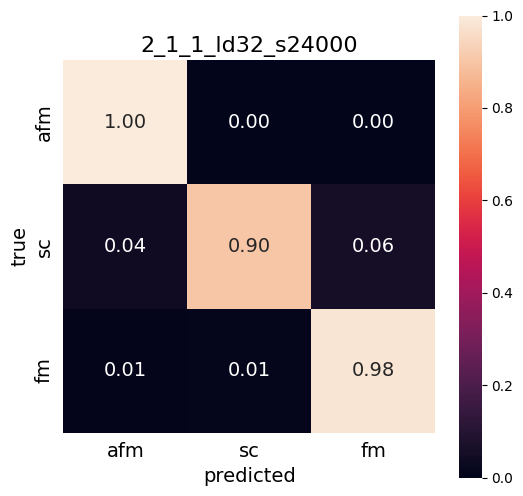

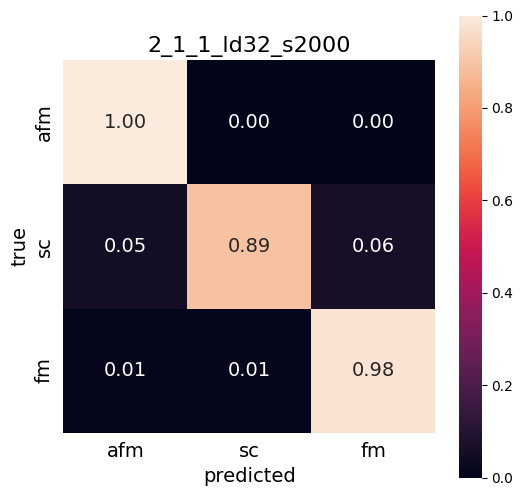

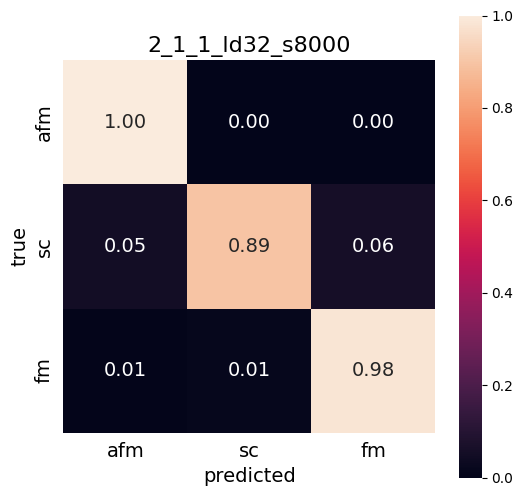

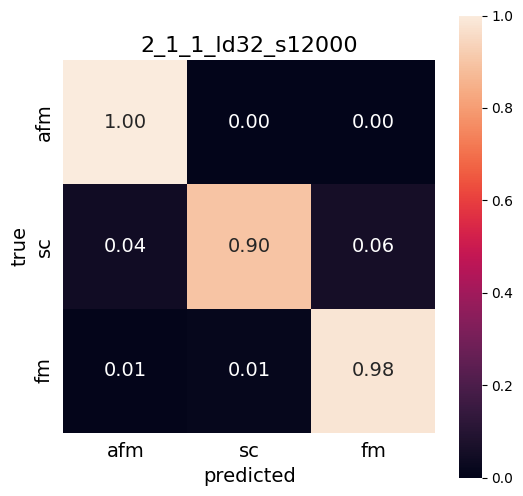

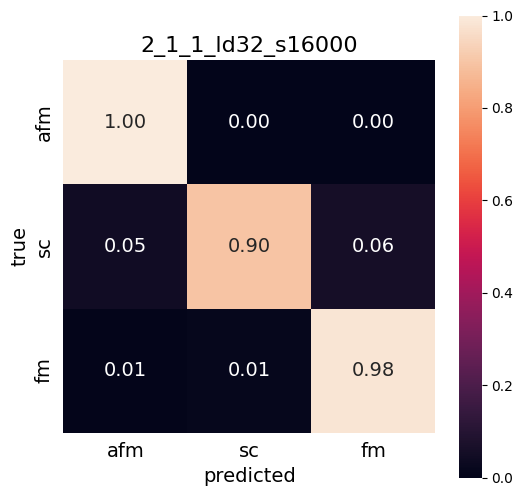

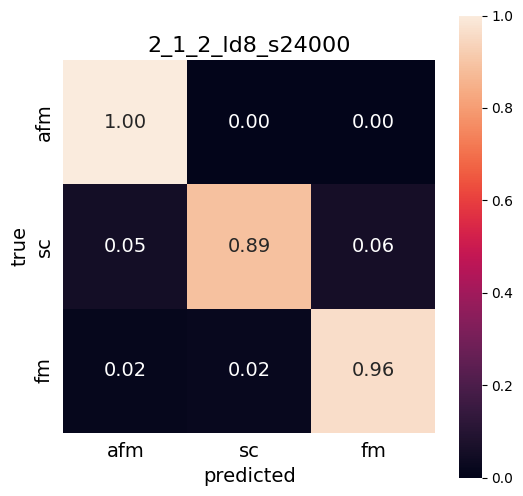

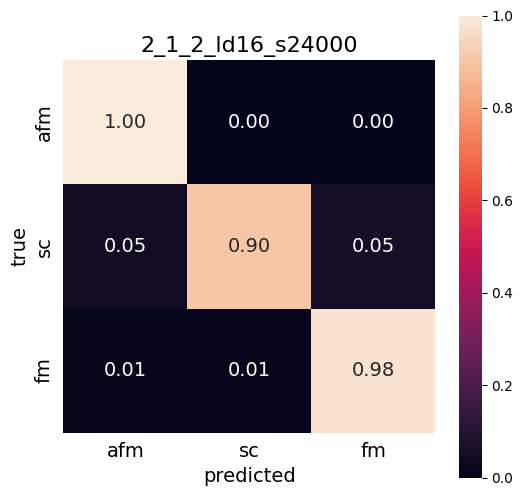

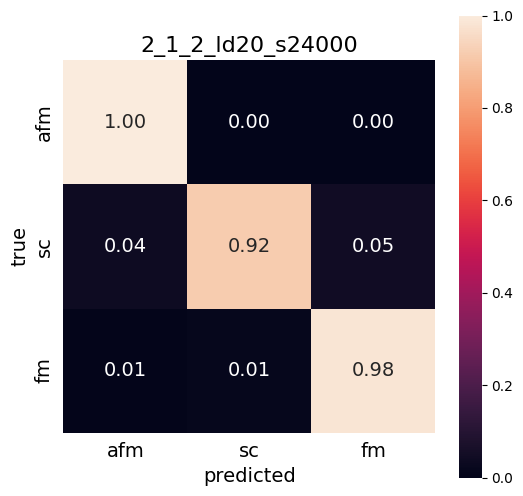

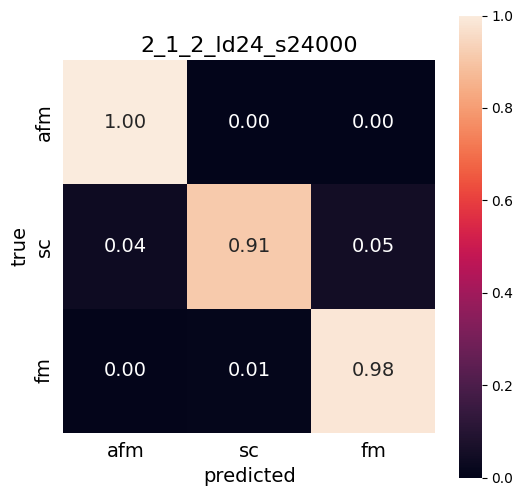

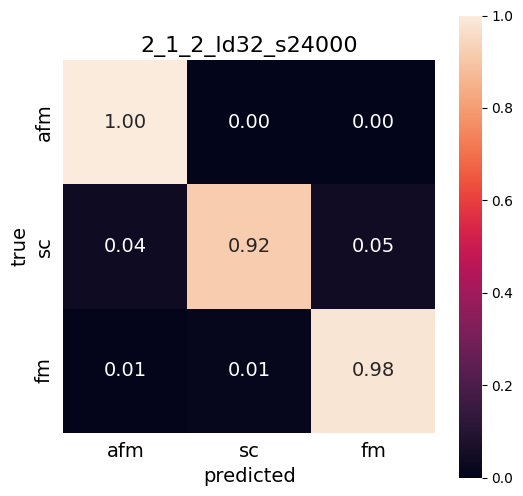

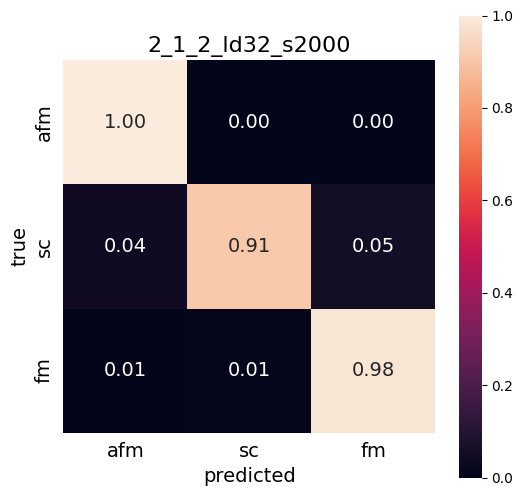

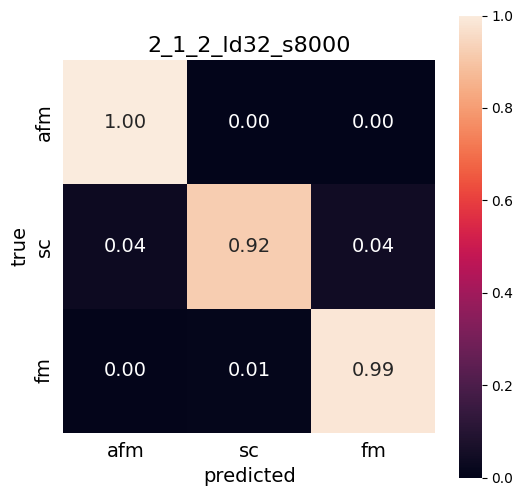

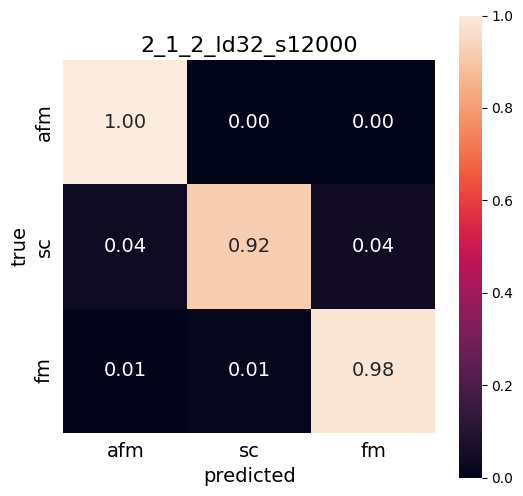

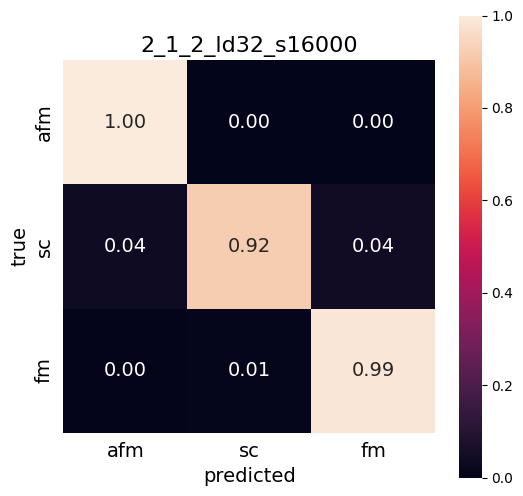

In [14]:
labels = list(AutoEncoderVertexDataset.phase_borders.keys())
for i, row in classification_df.iterrows():
    verteval.print_conf_mat(row['conf_mat'], f"{row['run_id']}_ld{row['ld']}_s{row['s']}", labels)

## compare vertex reconstructions

In [2]:
base_path = Path('/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/')
vertex_path_dict = {float(fp.stem[2:6]): fp for fp in data_dir.glob('*.h5')}

In [8]:
# set the run and tp-parameter for which you want to comparte original and reconstruction
runs_to_plot = ['2_1_1_ld8', '2_1_1_ld32']
tp_to_plot = [0.22, 0.33]

vertices = [AutoEncoderVertex24x6Dataset.load_from_file(vertex_path_dict[tp]) for tp in tp_to_plot]
predictions = {run_id: [np.load(base_path / run_id / 'predictions' / (vertex_path_dict[tp].stem + '.npy')) for tp in tp_to_plot] 
               for run_id in runs_to_plot}

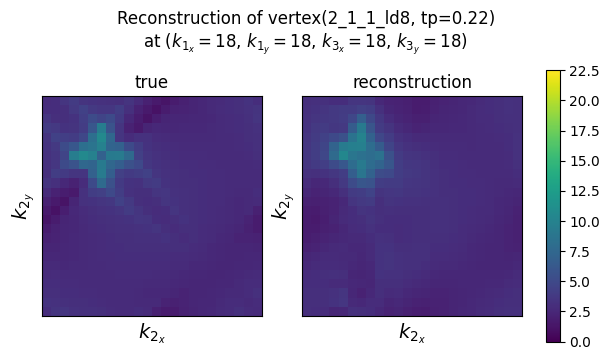

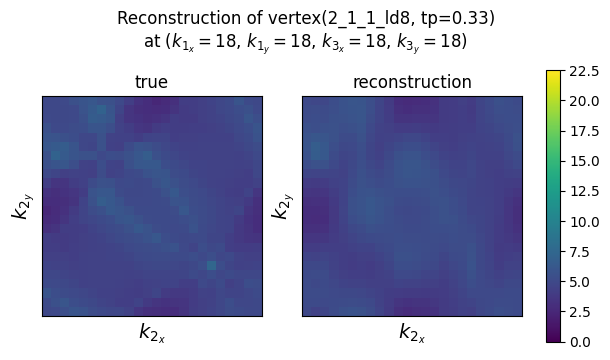

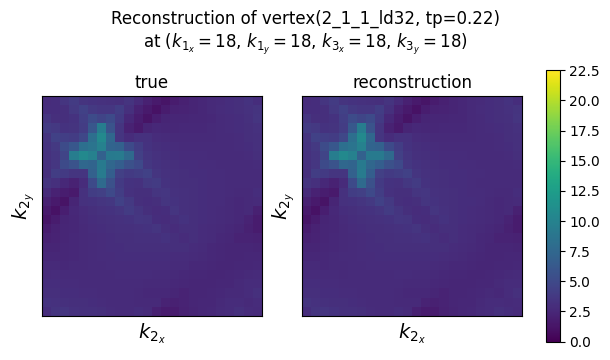

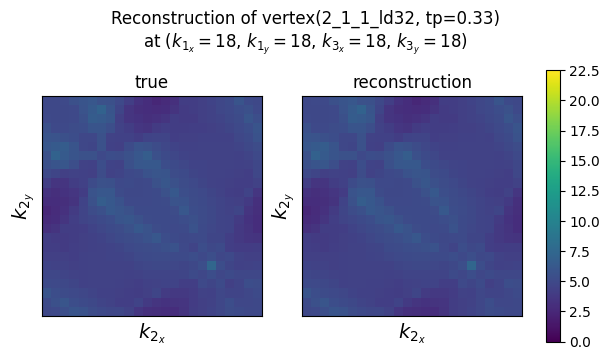

In [9]:
i = 18
axis = 3
nrows, ncols = 1, 2
slice_at = (i, i, i, i)
other_ks = set(range(1,4)) - {(axis + 1) // 2}
params_str = ', '.join([f'$k_{{{k}_{c}}}={sl}$' for (k, c), sl 
                        in zip([(k, c) for k in other_ks for c in ['x', 'y']], slice_at)])

for run_id, preds in predictions.items():
    for tp, true, pred in zip(tp_to_plot, vertices, preds):
        fn = vertex_path_dict[tp].stem
        true_slice = vertvis.get_mat_slice(true, axis, slice_at)
        pred_slice = vertvis.get_mat_slice(pred, axis, slice_at)
        plot_data = {'true': true_slice, 'reconstruction': pred_slice}
        vertvis.plot_compare_grid(plot_data, nrows, ncols, axis, None, figsize=(6, 4), 
                                  title=f'Reconstruction of vertex({run_id}, tp={tp})\nat ({params_str})', vmin=0.0, vmax=22.5)